# 03. Marginal-gradient null SDE calibration

This notebook fits the first null model: scale-dependent marginal OU dynamics for the coarse-grained gradient coupled to ellipsoid kinematics.  The purpose is not to produce the final closure, but to document the failure of a model that destroys strain--ellipsoid alignment.


# SDE calibration for the MEE ellipsoid train: $M=M^{(\mathrm{avg;out})}$, $g=g^{(\mathrm{out})}$

This notebook starts from the cleaned empirical train saved by the previous notebook and performs the first reduced-model calibration.

The empirical object is fixed throughout:

$$
(M,g)=(M^{(\mathrm{avg;out})},g^{(\mathrm{out})}).
$$

The goal is not to tune a model directly to final plots.  The goal is to identify the local generator of the empirical $(M,g)$ train and then validate by forward simulation.

The first model hierarchy is intentionally modest:

1. Fit a diagonal OU process for the three components of $M=(s_+,s_\times,\omega)$ in each $r$-bin.
2. Estimate the residual drift of the ellipsoid variables $v,\sigma$ after subtracting the material-advection contribution.
3. Forward simulate two baseline models:
   $$\mathcal M_0: \kappa=0,$$
   $$\mathcal M_1: \kappa(r)\text{ fitted from the nonlinear residual law}.$$

The notebook is designed as a reusable template for later DNS / RBC / aerodynamic-flow data: only the empirical input train changes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)

DATA_PATH = Path('empirical_train_mavg_out_v10b_enriched.npz')
if not DATA_PATH.exists():
    # fallback for execution from /mnt/data or from a copied notebook
    DATA_PATH = Path('empirical_train_mavg_out_v10b_enriched.npz')

FIG_DIR = Path('figs_sde_calibration_v10')
FIG_DIR.mkdir(exist_ok=True)

OUT_PATH = Path('sde_calibration_mavg_out_v10_results.npz')

print('Using data:', DATA_PATH.resolve())
print('Figures:', FIG_DIR.resolve())

Using data: /mnt/data/empirical_train_mavg_out_v10b_enriched.npz
Figures: /mnt/data/figs_sde_calibration_v10


## 1. Load the empirical train

The enriched empirical train already contains the primary observables derived from $(M,g)$:

$$
(s_+,s_\times,\omega), \quad v,\quad \sigma,\quad \theta_g,\quad r=e^v.
$$

We nevertheless keep the original arrays $M$ and $g$ available for consistency checks and possible later refinements.

In [2]:
z = np.load(DATA_PATH)
print('keys:', list(z.files))

times = z['times']
M = z['M']
g = z['g']
r_edges = z['r_edges']
r_centers = z['r_centers']

s_plus = z['s_plus']
s_cross = z['s_cross']
omega = z['omega']
v = z['v']
sigma = z['sigma']
theta = z['theta_g']
r = z['r']

R, T = s_plus.shape
dt = float(np.median(np.diff(times)))
nbins = len(r_centers)

m = np.stack([s_plus, s_cross, omega], axis=-1)

print(f'R={R} realizations, T={T} time samples, dt={dt:g}, nbins={nbins}')
print('r centers:', r_centers)
print('r edges:', r_edges)
print('sigma range:', np.nanmin(sigma), np.nanmax(sigma))
print('r range:', np.nanmin(r), np.nanmax(r))

keys: ['times', 'M', 'g', 'r_edges', 'r_centers', 'bin_idx', 's_plus', 's_cross', 'omega', 'v', 'sigma', 'theta_g', 'theta_s', 'r', 'sigma_mean', 'sigma_sem_seed', 'chi', 'chi_sem_seed', 'M2_red_mean', 'M2_red_sem_seed', 'M2_red_slope', 'M2_red_slope_se', 'alignment_mean', 'alignment_sem_seed']
R=12 realizations, T=1501 time samples, dt=0.01, nbins=7
r centers: [0.3144 0.4193 0.5591 0.7456 0.9944 1.326  1.7683]
r edges: [0.2723 0.3631 0.4842 0.6457 0.8611 1.1483 1.5313 2.042 ]
sigma range: 0.0020355506816782535 2.256825154119682
r range: 0.2060030009767877 2.3104696955516695


## 2. Utility functions

All statistics below use the same $r$-bins as the empirical notebook.  For generator estimates we use only pairs $(t,t+\Delta)$ whose initial state lies in the bin.  The lag $\Delta$ is chosen as a small multiple of the raw simulation time step to reduce numerical-noise sensitivity.

In [3]:
def bin_indices(x, edges):
    return np.digitize(x, edges) - 1


def bin_mask(x, k, edges):
    idx = bin_indices(x, edges)
    return idx == k


def sem_across_seeds(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) <= 1:
        return np.nan
    return vals.std(ddof=1) / np.sqrt(len(vals))


def seed_binned_stat(arr, r_arr, edges, func=np.nanmean):
    """Return seed-level binned statistic: mean over seeds and SEM across seeds."""
    R = arr.shape[0]
    nb = len(edges) - 1
    seed_vals = np.full((R, nb), np.nan)
    for i in range(R):
        for k in range(nb):
            sel = bin_mask(r_arr[i], k, edges)
            if np.sum(sel) > 3:
                seed_vals[i, k] = func(arr[i, sel])
    mean = np.nanmean(seed_vals, axis=0)
    sem = np.array([sem_across_seeds(seed_vals[:, k]) for k in range(nb)])
    return mean, sem, seed_vals


def interp_param(log_r, centers, values):
    """Log-r interpolation with clipping outside calibrated range."""
    centers = np.asarray(centers, float)
    values = np.asarray(values, float)
    ok = np.isfinite(values)
    if ok.sum() == 0:
        return np.zeros_like(log_r, dtype=float)
    if ok.sum() == 1:
        return np.full_like(log_r, values[ok][0], dtype=float)
    return np.interp(log_r, np.log(centers[ok]), values[ok], left=values[ok][0], right=values[ok][-1])


def coth_safe(x, eps=1e-3, maxval=50.0):
    x = np.asarray(x)
    y = 1.0 / np.tanh(np.maximum(x, eps))
    return np.minimum(y, maxval)


def wrap_angle_pi(theta):
    return np.mod(theta, np.pi)


def compute_Sprime_components(s_p, s_x, th):
    c2 = np.cos(2.0 * th)
    s2 = np.sin(2.0 * th)
    S11p = s_p * c2 + s_x * s2
    S12p = -s_p * s2 + s_x * c2
    return S11p, S12p


def empirical_diagnostics(s_p, s_x, om, sig, rr, edges, centers, label=''):
    sig_mean, sig_sem, _ = seed_binned_stat(sig, rr, edges, np.nanmean)
    M2_red = s_p**2 + s_x**2 + om**2
    M2_mean, M2_sem, _ = seed_binned_stat(M2_red, rr, edges, np.nanmean)

    chi_seed = np.full((s_p.shape[0], len(centers)), np.nan)
    for i in range(s_p.shape[0]):
        for k in range(len(centers)):
            sel = bin_mask(rr[i], k, edges)
            if np.sum(sel) > 5:
                vw = np.nanvar(om[i, sel])
                vs = np.nanvar(s_p[i, sel]) + np.nanvar(s_x[i, sel])
                chi_seed[i, k] = vw / vs if vs > 0 else np.nan
    chi_mean = np.nanmean(chi_seed, axis=0)
    chi_sem = np.array([sem_across_seeds(chi_seed[:, k]) for k in range(len(centers))])

    slope = np.nan
    slope_se = np.nan
    ok = np.isfinite(M2_mean) & (M2_mean > 0)
    if ok.sum() >= 3:
        x = np.log(centers[ok])
        y = np.log(M2_mean[ok])
        coeff = np.polyfit(x, y, 1)
        slope = coeff[0]
        yhat = coeff[0]*x + coeff[1]
        resid = y - yhat
        dof = max(len(x)-2, 1)
        s2res = np.sum(resid**2)/dof
        Sxx = np.sum((x-x.mean())**2)
        slope_se = np.sqrt(s2res/Sxx) if Sxx > 0 else np.nan
    return {
        'label': label,
        'sigma_mean': sig_mean,
        'sigma_sem': sig_sem,
        'M2_red_mean': M2_mean,
        'M2_red_sem': M2_sem,
        'chi_mean': chi_mean,
        'chi_sem': chi_sem,
        'M2_slope': slope,
        'M2_slope_se': slope_se,
    }

## 3. Empirical reference diagnostics

These are the empirical diagnostics against which the forward SDE simulations will be compared.  They are not fitting targets except indirectly through the generator estimates.

We use the reduced norm

$$
|M|_{\mathrm{red}}^2=s_+^2+s_\times^2+\omega^2.
$$

The Frobenius norm is $\mathrm{tr}(M^\top M)=2|M|_{\mathrm{red}}^2$.

Empirical sigma mean: [1.032  1.0842 1.117  1.044  1.0347 0.831  0.8351]
Empirical chi: [1.0863 1.1732 0.882  1.1102 0.9206 1.3045 1.0976]
Empirical M2_red slope = -1.990 ± 0.131


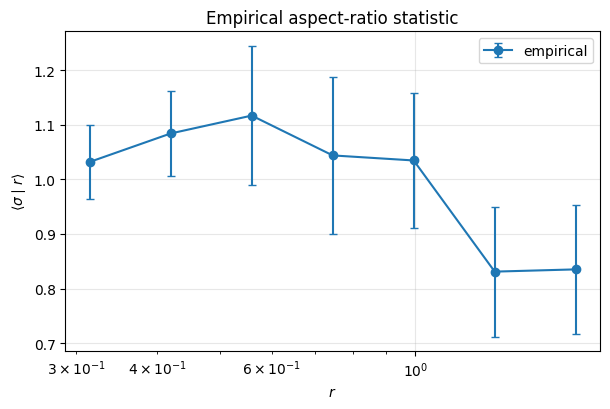

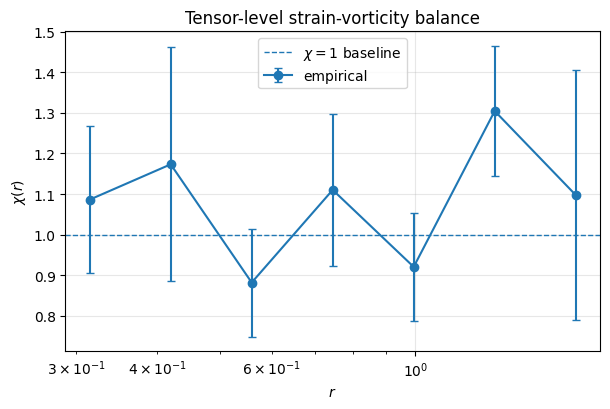

In [4]:
emp = empirical_diagnostics(s_plus, s_cross, omega, sigma, r, r_edges, r_centers, label='empirical')

print('Empirical sigma mean:', emp['sigma_mean'])
print('Empirical chi:', emp['chi_mean'])
print(f"Empirical M2_red slope = {emp['M2_slope']:.3f} ± {emp['M2_slope_se']:.3f}")

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(r_centers, emp['sigma_mean'], yerr=emp['sigma_sem'], marker='o', capsize=3, label='empirical')
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\langle \sigma\mid r\rangle$')
ax.set_title('Empirical aspect-ratio statistic')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/'empirical_sigma_mean.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(r_centers, emp['chi_mean'], yerr=emp['chi_sem'], marker='o', capsize=3, label='empirical')
ax.axhline(1.0, linestyle='--', linewidth=1.0, label=r'$\chi=1$ baseline')
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\chi(r)$')
ax.set_title('Tensor-level strain-vorticity balance')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/'empirical_chi.png', dpi=180)
plt.show()

## 4. Calibrate the OU driving process for $M$

We fit a diagonal OU model for each component $m_a\in\{s_+,s_\times,\omega\}$ in each $r$-bin:

$$
dm_a=-\frac{m_a}{\tau_a(r)}dt+\sqrt{2D_a(r)}dW_a.
$$

For a lag $\Delta$, the stationary OU relations are

$$
C_\Delta^{(a)}=C_0^{(a)}\exp(-\Delta/\tau_a),
$$

so

$$
\tau_a(r)=-\frac{\Delta}{\log(C_\Delta^{(a)}/C_0^{(a)})},
\qquad
D_a(r)=\frac{C_0^{(a)}}{\tau_a(r)}.
$$

The strain channel is averaged over $s_+$ and $s_\times$ after estimating them separately.  This can later be replaced by a full VAR model if the off-diagonal lag covariance is important.

In [5]:
LAG_STEPS = 5
lag_dt = LAG_STEPS * dt
components = ['s_plus', 's_cross', 'omega']
comp_arrays = [s_plus, s_cross, omega]

C0 = np.full((nbins, 3), np.nan)
Cd = np.full((nbins, 3), np.nan)
rho = np.full((nbins, 3), np.nan)
tau_comp = np.full((nbins, 3), np.nan)
D_comp = np.full((nbins, 3), np.nan)
N_pairs = np.zeros(nbins, dtype=int)

for k in range(nbins):
    sel0 = (r[:, :-LAG_STEPS] >= r_edges[k]) & (r[:, :-LAG_STEPS] < r_edges[k+1])
    N_pairs[k] = int(sel0.sum())
    for j, arr in enumerate(comp_arrays):
        x = arr[:, :-LAG_STEPS][sel0]
        y = arr[:, LAG_STEPS:][sel0]
        if len(x) < 20:
            continue
        x = x - np.mean(x)
        y = y - np.mean(y)
        c0 = np.mean(x*x)
        cd = np.mean(x*y)
        rrho = cd / c0 if c0 > 0 else np.nan
        # OU requires positive correlation below 1.  Clipping prevents numerical explosions;
        # the raw rho is still printed below.
        rrho_clip = np.clip(rrho, 1e-4, 0.999)
        tau = -lag_dt / np.log(rrho_clip)
        D = c0 / tau
        C0[k, j] = c0
        Cd[k, j] = cd
        rho[k, j] = rrho
        tau_comp[k, j] = tau
        D_comp[k, j] = D

# Average the two strain components for the first baseline.
tau_s = np.nanmean(tau_comp[:, :2], axis=1)
D_s = np.nanmean(D_comp[:, :2], axis=1)
tau_w = tau_comp[:, 2]
D_w = D_comp[:, 2]

print('lag_dt =', lag_dt)
print('N pairs per bin:', N_pairs)
print('\nraw rho by bin [s_plus, s_cross, omega]:')
print(rho)
print('\ntau_s, tau_w:')
print(np.c_[tau_s, tau_w])
print('\nD_s, D_w:')
print(np.c_[D_s, D_w])

lag_dt = 0.049999999999998934
N pairs per bin: [1536 1705 1981 3014 3819 3055 1327]

raw rho by bin [s_plus, s_cross, omega]:
[[0.8507 0.8074 0.876 ]
 [0.8718 0.8666 0.8703]
 [0.9076 0.8816 0.8966]
 [0.8753 0.9206 0.931 ]
 [0.9112 0.9043 0.9033]
 [0.8835 0.9126 0.9159]
 [0.8696 0.9301 0.8948]]

tau_s, tau_w:
[[0.2714 0.3775]
 [0.3569 0.3599]
 [0.4563 0.458 ]
 [0.49   0.6996]
 [0.5175 0.4918]
 [0.4752 0.5691]
 [0.5238 0.45  ]]

D_s, D_w:
[[0.7578 1.5927]
 [0.4204 0.9022]
 [0.2227 0.4373]
 [0.1247 0.2302]
 [0.0633 0.1184]
 [0.0323 0.0721]
 [0.0153 0.0304]]


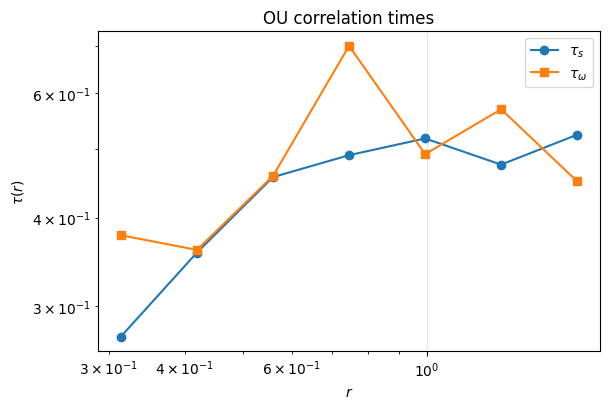

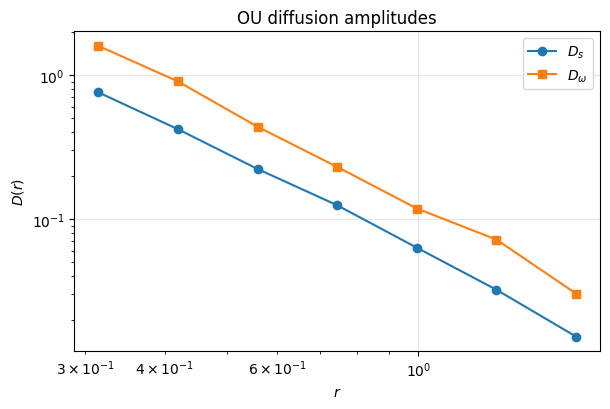

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(r_centers, tau_s, marker='o', label=r'$\tau_s$')
ax.plot(r_centers, tau_w, marker='s', label=r'$\tau_\omega$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\tau(r)$')
ax.set_title('OU correlation times')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/'ou_tau.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(r_centers, D_s, marker='o', label=r'$D_s$')
ax.plot(r_centers, D_w, marker='s', label=r'$D_\omega$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel('$D(r)$')
ax.set_title('OU diffusion amplitudes')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/'ou_D.png', dpi=180)
plt.show()

## 5. Estimate the residual drift of $g$

The material ellipsoid contribution is

$$
\dot g = Mg+gM^\top.
$$

In principal-axis variables, the material part gives

$$
\dot\sigma_{\mathrm{mat}}=2S'_{11},
$$

where

$$
S'_{11}=s_+\cos 2\theta + s_\times\sin 2\theta.
$$

The reduced model adds volume drift and optional nonlinear aspect-ratio relaxation:

$$
\dot v=-\frac{1}{2}\gamma(r),
$$

$$
\dot\sigma=2S'_{11}-\frac{1}{2}\kappa(r)\sinh(2\sigma).
$$

Therefore the empirical residuals are

$$
R_v=\dot v,
\qquad
R_\sigma=\dot\sigma-2S'_{11}.
$$

We estimate

$$
\gamma(r)=-2\langle R_v\mid r\rangle,
$$

and fit $\kappa(r)$ by least squares in

$$
R_\sigma=-\frac{1}{2}\kappa(r)\sinh(2\sigma)+\varepsilon.
$$

In [7]:
# Forward differences, located at t.
dv = (v[:, 1:] - v[:, :-1]) / dt
dsig = (sigma[:, 1:] - sigma[:, :-1]) / dt
r0 = r[:, :-1]
sig0 = sigma[:, :-1]
th0 = theta[:, :-1]
sp0 = s_plus[:, :-1]
sx0 = s_cross[:, :-1]
om0 = omega[:, :-1]

S11p, S12p = compute_Sprime_components(sp0, sx0, th0)
R_v = dv
R_sig = dsig - 2.0*S11p
X_kappa = np.sinh(2.0 * sig0)

gamma = np.full(nbins, np.nan)
gamma_sem = np.full(nbins, np.nan)
kappa_raw = np.full(nbins, np.nan)
kappa_sem_seed = np.full(nbins, np.nan)
Rsig_mean = np.full(nbins, np.nan)
Rsig_std = np.full(nbins, np.nan)

# seed-level gamma and kappa for SEM
seed_gamma = np.full((R, nbins), np.nan)
seed_kappa = np.full((R, nbins), np.nan)

for i in range(R):
    for k in range(nbins):
        sel = (r0[i] >= r_edges[k]) & (r0[i] < r_edges[k+1])
        if np.sum(sel) > 10:
            seed_gamma[i, k] = -2.0*np.mean(R_v[i, sel])
            X = X_kappa[i, sel]
            Y = R_sig[i, sel]
            denom = np.sum(X*X)
            if denom > 0:
                seed_kappa[i, k] = -2.0*np.sum(X*Y)/denom

for k in range(nbins):
    sel = (r0 >= r_edges[k]) & (r0 < r_edges[k+1])
    if np.sum(sel) > 20:
        gamma[k] = -2.0*np.mean(R_v[sel])
        gamma_sem[k] = sem_across_seeds(seed_gamma[:, k])
        X = X_kappa[sel]
        Y = R_sig[sel]
        denom = np.sum(X*X)
        if denom > 0:
            kappa_raw[k] = -2.0*np.sum(X*Y)/denom
        kappa_sem_seed[k] = sem_across_seeds(seed_kappa[:, k])
        Rsig_mean[k] = np.mean(Y)
        Rsig_std[k] = np.std(Y)

# For stable forward simulations, the default fitted-kappa model uses only damping.
kappa_nonneg = np.maximum(kappa_raw, 0.0)

print('gamma(r):')
print(gamma)
print('kappa_raw(r):')
print(kappa_raw)
print('kappa_nonneg(r) used by default for M1:')
print(kappa_nonneg)
print('mean R_sigma per bin:')
print(Rsig_mean)

gamma(r):
[-0.45   -0.4039 -0.3488 -0.2287 -0.1805 -0.194  -0.1774]
kappa_raw(r):
[0.1781 0.0814 0.062  0.0345 0.0467 0.0632 0.101 ]
kappa_nonneg(r) used by default for M1:
[0.1781 0.0814 0.062  0.0345 0.0467 0.0632 0.101 ]
mean R_sigma per bin:
[-0.3649 -0.3251 -0.2435 -0.1798 -0.1318 -0.1608 -0.1523]


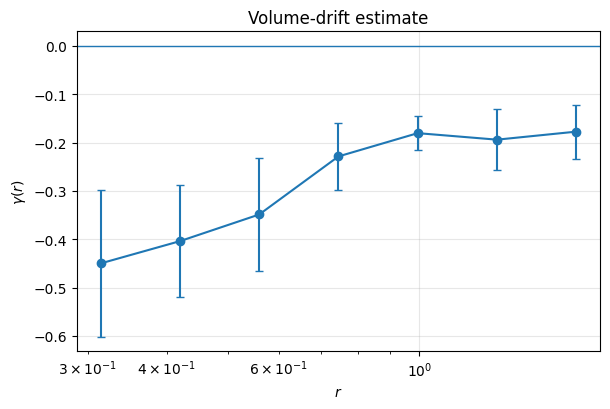

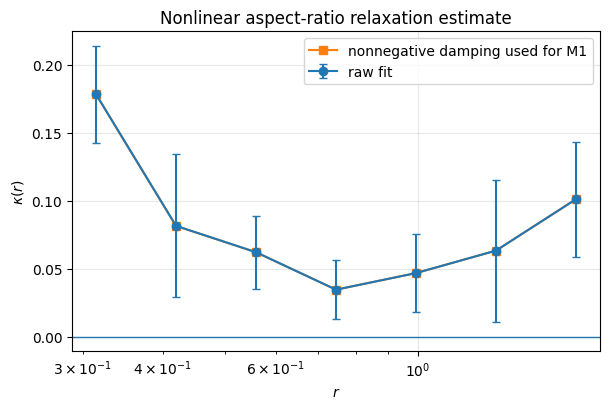

In [8]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(r_centers, gamma, yerr=gamma_sem, marker='o', capsize=3)
ax.axhline(0.0, linewidth=1.0)
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\gamma(r)$')
ax.set_title('Volume-drift estimate')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR/'gamma_estimate.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(r_centers, kappa_raw, yerr=kappa_sem_seed, marker='o', capsize=3, label='raw fit')
ax.plot(r_centers, kappa_nonneg, marker='s', label='nonnegative damping used for M1')
ax.axhline(0.0, linewidth=1.0)
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\kappa(r)$')
ax.set_title('Nonlinear aspect-ratio relaxation estimate')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/'kappa_estimate.png', dpi=180)
plt.show()

## 6. Forward simulation of the calibrated SDE

We simulate the principal-axis form.  The OU process drives the components of $M$ in the lab frame:

$$
ds_+=-\frac{s_+}{\tau_s(r)}dt+\sqrt{2D_s(r)}dW_+,
$$

$$
ds_\times=-\frac{s_\times}{\tau_s(r)}dt+\sqrt{2D_s(r)}dW_\times,
$$

$$
d\omega=-\frac{\omega}{\tau_\omega(r)}dt+\sqrt{2D_\omega(r)}dW_\omega.
$$

The ellipsoid evolves as

$$
\dot v=-\frac{1}{2}\gamma(r),
$$

$$
\dot\sigma=2S'_{11}-\frac{1}{2}\kappa(r)\sinh(2\sigma),
$$

$$
\dot\theta=-\omega-S'_{12}\coth\sigma.
$$

The sign convention in the last equation follows the convention used in the notes.  If a later direct $g$-matrix simulation is preferred, this orientation equation can be replaced by integrating $\dot g=Mg+gM^\top$ plus residual drift directly.

In [9]:
def simulate_sde(model_name, kappa_values, seed=1234, n_realizations=None):
    rng = np.random.default_rng(seed)
    if n_realizations is None:
        n_realizations = R
    nT = len(times)

    sp = np.zeros((n_realizations, nT))
    sx = np.zeros((n_realizations, nT))
    om = np.zeros((n_realizations, nT))
    vv = np.zeros((n_realizations, nT))
    sig = np.zeros((n_realizations, nT))
    th = np.zeros((n_realizations, nT))

    # Initial conditions: resample empirical initial states.
    init_idx = rng.integers(0, R, size=n_realizations)
    sp[:, 0] = s_plus[init_idx, 0]
    sx[:, 0] = s_cross[init_idx, 0]
    om[:, 0] = omega[init_idx, 0]
    vv[:, 0] = v[init_idx, 0]
    sig[:, 0] = np.maximum(sigma[init_idx, 0], 1e-4)
    th[:, 0] = theta[init_idx, 0]

    sqrt_dt = np.sqrt(dt)
    for n in range(nT-1):
        rr = np.exp(vv[:, n])
        log_rr = np.log(np.maximum(rr, 1e-12))

        ts = interp_param(log_rr, r_centers, tau_s)
        tw = interp_param(log_rr, r_centers, tau_w)
        Ds = interp_param(log_rr, r_centers, D_s)
        Dw = interp_param(log_rr, r_centers, D_w)
        gam = interp_param(log_rr, r_centers, gamma)
        kap = interp_param(log_rr, r_centers, kappa_values)

        ts = np.maximum(ts, 1e-5)
        tw = np.maximum(tw, 1e-5)
        Ds = np.maximum(Ds, 0.0)
        Dw = np.maximum(Dw, 0.0)

        sp[:, n+1] = sp[:, n] + (-sp[:, n]/ts)*dt + np.sqrt(2*Ds)*sqrt_dt*rng.standard_normal(n_realizations)
        sx[:, n+1] = sx[:, n] + (-sx[:, n]/ts)*dt + np.sqrt(2*Ds)*sqrt_dt*rng.standard_normal(n_realizations)
        om[:, n+1] = om[:, n] + (-om[:, n]/tw)*dt + np.sqrt(2*Dw)*sqrt_dt*rng.standard_normal(n_realizations)

        S11, S12 = compute_Sprime_components(sp[:, n], sx[:, n], th[:, n])
        vv[:, n+1] = vv[:, n] + (-0.5*gam)*dt
        sig_next = sig[:, n] + (2.0*S11 - 0.5*kap*np.sinh(2.0*np.clip(sig[:, n], 0, 6)))*dt
        sig[:, n+1] = np.maximum(sig_next, 1e-4)
        th[:, n+1] = wrap_angle_pi(th[:, n] + (-om[:, n] - S12*coth_safe(sig[:, n]))*dt)

        # prevent rare runaway values from destroying the diagnostic plots
        sig[:, n+1] = np.minimum(sig[:, n+1], 8.0)
        vv[:, n+1] = np.clip(vv[:, n+1], np.log(r_edges[0]/2), np.log(r_edges[-1]*2))

    rr = np.exp(vv)
    return {
        'label': model_name,
        's_plus': sp,
        's_cross': sx,
        'omega': om,
        'v': vv,
        'sigma': sig,
        'theta': th,
        'r': rr,
    }

sim_M0 = simulate_sde('M0: kappa=0', np.zeros_like(kappa_nonneg), seed=20260524)
sim_M1 = simulate_sde('M1: fitted nonnegative kappa', kappa_nonneg, seed=20260525)

print('M0 sigma range:', np.nanmin(sim_M0['sigma']), np.nanmax(sim_M0['sigma']))
print('M1 sigma range:', np.nanmin(sim_M1['sigma']), np.nanmax(sim_M1['sigma']))

M0 sigma range: 0.0001 0.2568574698325797
M1 sigma range: 0.0001 0.16151842922513537


## 7. Forward-validation diagnostics

The SDE was not fitted to $\langle\sigma\mid r\rangle$, $\chi(r)$, or the observed $M$-scaling.  These are validation summaries.

The comparison answers three questions:

1. Does the SDE reproduce $O(1)$ aspect-ratio saturation?
2. Does it preserve the tensor-level balance $\chi(r)$?
3. Does the OU fit reproduce the observed scale dependence of $|M|_{\mathrm{red}}^2$?

In [10]:
diag_M0 = empirical_diagnostics(sim_M0['s_plus'], sim_M0['s_cross'], sim_M0['omega'], sim_M0['sigma'], sim_M0['r'], r_edges, r_centers, label=sim_M0['label'])
diag_M1 = empirical_diagnostics(sim_M1['s_plus'], sim_M1['s_cross'], sim_M1['omega'], sim_M1['sigma'], sim_M1['r'], r_edges, r_centers, label=sim_M1['label'])

for d in [emp, diag_M0, diag_M1]:
    print(d['label'])
    print('  sigma:', d['sigma_mean'])
    print('  chi:', d['chi_mean'])
    print(f"  M2 slope: {d['M2_slope']:.3f} ± {d['M2_slope_se']:.3f}")

empirical
  sigma: [1.032  1.0842 1.117  1.044  1.0347 0.831  0.8351]
  chi: [1.0863 1.1732 0.882  1.1102 0.9206 1.3045 1.0976]
  M2 slope: -1.990 ± 0.131
M0: kappa=0
  sigma: [0.0098 0.0013 0.0079 0.0071 0.0074 0.0033 0.0056]
  chi: [1.4092 0.9811 1.2546 1.0462 1.1362 1.383  1.3138]
  M2 slope: -1.578 ± 0.082
M1: fitted nonnegative kappa
  sigma: [0.0013 0.0019 0.002  0.0018 0.0004 0.0006 0.004 ]
  chi: [1.5488 1.2242 1.1003 0.7614 1.3294 1.156  1.7647]
  M2 slope: -1.831 ± 0.136


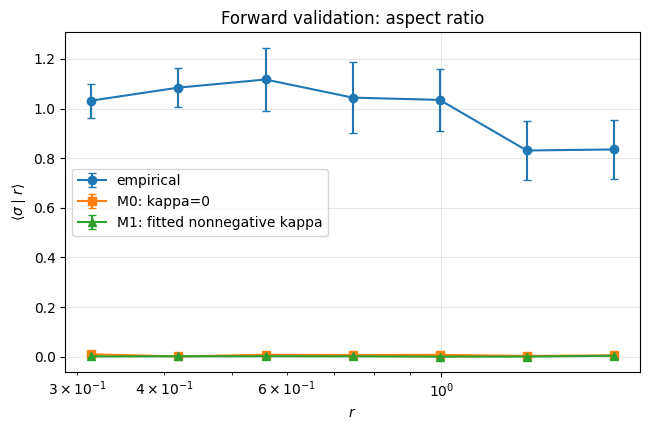

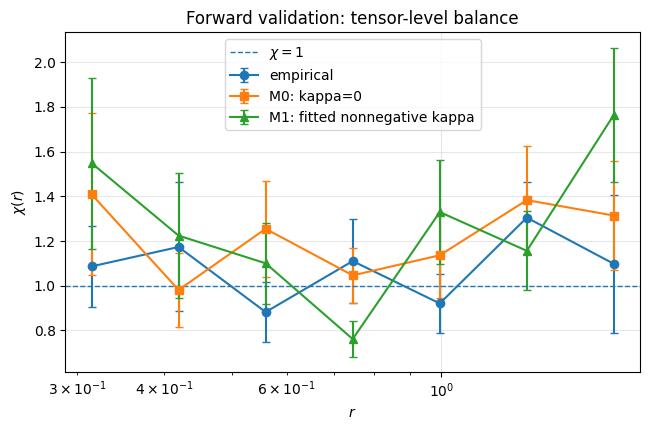

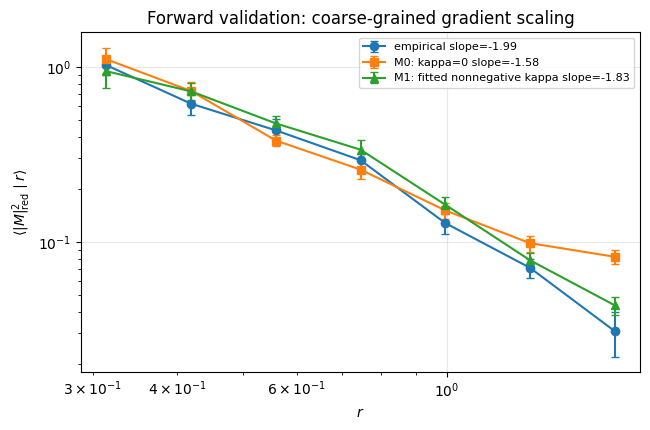

In [11]:
fig, ax = plt.subplots(figsize=(6.6, 4.4))
for d, marker in [(emp, 'o'), (diag_M0, 's'), (diag_M1, '^')]:
    ax.errorbar(r_centers, d['sigma_mean'], yerr=d['sigma_sem'], marker=marker, capsize=3, label=d['label'])
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\langle\sigma\mid r\rangle$')
ax.set_title('Forward validation: aspect ratio')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/'validation_sigma_mean.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6.6, 4.4))
for d, marker in [(emp, 'o'), (diag_M0, 's'), (diag_M1, '^')]:
    ax.errorbar(r_centers, d['chi_mean'], yerr=d['chi_sem'], marker=marker, capsize=3, label=d['label'])
ax.axhline(1.0, linestyle='--', linewidth=1.0, label=r'$\chi=1$')
ax.set_xscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\chi(r)$')
ax.set_title('Forward validation: tensor-level balance')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR/'validation_chi.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6.6, 4.4))
for d, marker in [(emp, 'o'), (diag_M0, 's'), (diag_M1, '^')]:
    ax.errorbar(r_centers, d['M2_red_mean'], yerr=d['M2_red_sem'], marker=marker, capsize=3, label=f"{d['label']} slope={d['M2_slope']:.2f}")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$\langle |M|_{\mathrm{red}}^2\mid r\rangle$')
ax.set_title('Forward validation: coarse-grained gradient scaling')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR/'validation_M2_scaling.png', dpi=180)
plt.show()

## 8. Residual diagnostics for the generator fit

A useful next check is whether the residual

$$
\varepsilon_\sigma=R_\sigma+\frac{1}{2}\kappa(r)\sinh(2\sigma)
$$

has systematic dependence on $\sigma$ or $r$.  If it does, the scalar law $\kappa(r)$ is insufficient and one should move to $\kappa(r,\sigma)$ or to a learned residual drift.

<>:22: SyntaxWarning: invalid escape sequence '\k'
<>:22: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_3839/1985108813.py:22: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title('Residual structure after fitted $\kappa(r)$')


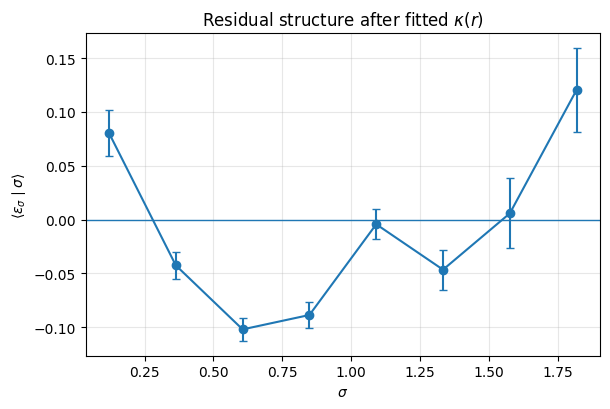

In [12]:
# Residual using the nonnegative kappa used in M1.
kap_at_data = interp_param(np.log(np.maximum(r0, 1e-12)), r_centers, kappa_nonneg)
eps_sig = R_sig + 0.5 * kap_at_data * X_kappa

# Bin in sigma for a simple residual-structure check.
sig_edges = np.linspace(0.0, np.nanpercentile(sig0, 99), 9)
sig_centers = 0.5*(sig_edges[:-1] + sig_edges[1:])
eps_mean = np.full(len(sig_centers), np.nan)
eps_sem = np.full(len(sig_centers), np.nan)
for j in range(len(sig_centers)):
    sel = (sig0 >= sig_edges[j]) & (sig0 < sig_edges[j+1]) & np.isfinite(eps_sig)
    if sel.sum() > 20:
        vals = eps_sig[sel]
        eps_mean[j] = vals.mean()
        eps_sem[j] = vals.std(ddof=1)/np.sqrt(len(vals))

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(sig_centers, eps_mean, yerr=eps_sem, marker='o', capsize=3)
ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$\langle \varepsilon_\sigma\mid \sigma\rangle$')
ax.set_title('Residual structure after fitted $\kappa(r)$')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR/'sigma_residual_vs_sigma.png', dpi=180)
plt.show()

## 9. Save calibration results

The saved file contains the calibrated parameters and the forward-validation summaries.  This can be used by the notes or by a later notebook that implements a richer generator model.

In [13]:
np.savez_compressed(
    OUT_PATH,
    r_edges=r_edges,
    r_centers=r_centers,
    dt=dt,
    lag_steps=LAG_STEPS,
    lag_dt=lag_dt,
    C0=C0,
    Cd=Cd,
    rho=rho,
    tau_comp=tau_comp,
    D_comp=D_comp,
    tau_s=tau_s,
    D_s=D_s,
    tau_w=tau_w,
    D_w=D_w,
    gamma=gamma,
    gamma_sem=gamma_sem,
    kappa_raw=kappa_raw,
    kappa_sem_seed=kappa_sem_seed,
    kappa_nonneg=kappa_nonneg,
    emp_sigma_mean=emp['sigma_mean'],
    emp_chi=emp['chi_mean'],
    emp_M2_red_mean=emp['M2_red_mean'],
    M0_sigma_mean=diag_M0['sigma_mean'],
    M0_chi=diag_M0['chi_mean'],
    M0_M2_red_mean=diag_M0['M2_red_mean'],
    M1_sigma_mean=diag_M1['sigma_mean'],
    M1_chi=diag_M1['chi_mean'],
    M1_M2_red_mean=diag_M1['M2_red_mean'],
)
print('saved:', OUT_PATH.resolve())

saved: /mnt/data/sde_calibration_mavg_out_v10_results.npz


## 10. Interpretation checklist

Use the following checklist after executing the notebook:

1. If $\tau_s(r)$ and $\tau_\omega(r)$ are nearly identical and $\chi(r)\simeq 1$, the isotropic incompressible baseline is adequate for $M$.
2. If $\mathcal M_0$ already reproduces $\langle\sigma\mid r\rangle$, then shape saturation is mostly alignment-induced and no direct $\kappa$ term is needed at this level.
3. If $\mathcal M_0$ fails and $\mathcal M_1$ succeeds, then the nonlinear aspect-ratio relaxation term is empirically useful.
4. If both fail, the residual drift is not captured by $\gamma(r)$ and $\kappa(r)$ alone.  The next candidates are $\kappa(r,\sigma)$, a full VAR model for $M$, a stochastic Neural ODE/SDE in physical time, or a diffusion model in physical time for the conditional transition of $(M,g)$.

The important point is that each refinement should be triggered by a specific residual diagnostic, not by direct visual fitting of the final phenomenology.